In [32]:
import time

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END, MessagesState

FIRST_STAGE = "first_stage"
SECOND_STAGE = "second_stage"
FINAL_STAGE = "final_stage"

In [33]:
process_status = {"is_interruption": True}

In [34]:
class MsgState(MessagesState):
    user_request:str
    response:str

In [35]:
def process_first_stage(state: MsgState):
    print("\nFirst Stage Process Begins...")
    state["user_request"] = state["user_request"] + "- Stage One"
    state["response"] = f"{state["user_request"]} - Clearance from First stage process"
    print(state)
    return state

def process_second_stage(state: MsgState):
    print("\nSecond Stage Process Begins...")
    state["user_request"] = state["user_request"] + "- Stage Two"
    time.sleep(3)
    if process_status["is_interruption"]:
        process_status["is_interruption"] = False
        print("\nProcess Interrupted")
        raise ValueError("interrupted due to raw material mix")
    state["response"] = f"{state["user_request"]} - Clearance from Second stage process"
    print(state)
    return state

def process_final_stage(state:MsgState):
    print("\nFinal Stage Process Begins...")
    state["user_request"] = state["user_request"] + "- Process Completed"
    state["response"] = f"{state["user_request"]} - Final Clearance -- Product is ready"
    print(state)
    return state

In [36]:
wf_graph = StateGraph(MsgState)
wf_graph.add_node(FIRST_STAGE, process_first_stage)
wf_graph.add_node(SECOND_STAGE, process_second_stage)
wf_graph.add_node(FINAL_STAGE, process_final_stage)

wf_graph.add_edge(START, FIRST_STAGE)
wf_graph.add_edge(FIRST_STAGE, SECOND_STAGE)
wf_graph.add_edge(SECOND_STAGE, FINAL_STAGE)
wf_graph.add_edge(FINAL_STAGE, END)

in_memory_checkpoint = InMemorySaver()
graph = wf_graph.compile(in_memory_checkpoint)

### Process Graph

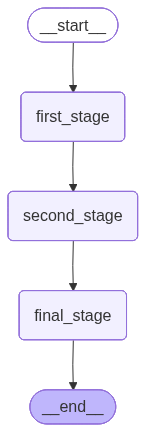

In [37]:
from IPython.display import display, Image
display(Image(graph.get_graph().draw_mermaid_png()))

### Execute with Interruption / Exception

In [38]:
configs = {"configurable":{"thread_id":"user-1"}}
try:
    #response = graph.invoke({"messages":[{"user_request":"Refine Oil"}]}, configs)
    #response = graph.invoke({"messages":[{"role":"user", "content":"Refine Oil"}]}, configs)
    response = graph.invoke({"user_request":"Refine Oil"}, config=configs)
    #print(response)
except KeyboardInterrupt as ke:
    print(f"Power cut interrupt : {ke}")
except Exception as e:
    print(f"Interruption : {e}")


First Stage Process Begins...
{'messages': [], 'user_request': 'Refine Oil- Stage One', 'response': 'Refine Oil- Stage One - Clearance from First stage process'}

Second Stage Process Begins...

Process Interrupted
Interruption : interrupted due to raw material mix


### State Sanpshot - History

In [39]:
print(list(graph.get_state_history(config=configs)))

[StateSnapshot(values={'messages': [], 'user_request': 'Refine Oil- Stage One', 'response': 'Refine Oil- Stage One - Clearance from First stage process'}, next=('second_stage',), config={'configurable': {'thread_id': 'user-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17ebfe-0b75-6036-8001-0c520f376d9a'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-07-13T13:36:39.915928+00:00', parent_config={'configurable': {'thread_id': 'user-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17ebfe-0b73-6e66-8000-62225faaf110'}}, tasks=(PregelTask(id='1b1548c7-6b6e-1448-169b-1cba4fd5c82e', name='second_stage', path=('__pregel_pull', 'second_stage'), error="ValueError('interrupted due to raw material mix')", interrupts=(), state=None, result=None),), interrupts=()), StateSnapshot(values={'messages': [], 'user_request': 'Refine Oil'}, next=('first_stage',), config={'configurable': {'thread_id': 'user-1', 'checkpoint_ns': '', 'checkpoint_id': '1f17ebfe-0b73-6e66-8000-62225faaf110'

### Execute - Post Interruption / Exception

In [40]:
configs = {"configurable":{"thread_id":"user-1"}}
try:
    response = graph.invoke(None, config=configs)
except Exception as e:
    print(f"Interruption : {e}")


Second Stage Process Begins...
{'messages': [], 'user_request': 'Refine Oil- Stage One- Stage Two', 'response': 'Refine Oil- Stage One- Stage Two - Clearance from Second stage process'}

Final Stage Process Begins...
{'messages': [], 'user_request': 'Refine Oil- Stage One- Stage Two- Process Completed', 'response': 'Refine Oil- Stage One- Stage Two- Process Completed - Final Clearance -- Product is ready'}


### Execute - On Completion

In [41]:
configs = {"configurable":{"thread_id":"user-1"}}
try:
    response = graph.invoke(None, config=configs)
except Exception as e:
    print(f"Interruption : {e}")

In [ ]:
configs1 = {"configurable":{"thread_id":"user-2"}}
response = graph.invoke({"user_request":"Refine Palm Oil"}, config=configs1)
print(response)

In [ ]:
#print(in_memory_checkpoint.get(config=configs1))
in_memory_checkpoint.get_tuple(config=configs)